# 05. Compact BiLSTM

This notebook is dedicated to a single POS-tagging model: **Compact BiLSTM**.

It contains:
- the minimal benchmark-loading utilities
- the implementation of this model only
- shared evaluation helpers
- one training/evaluation run
- inline plots and error analysis for this model


## Model Role

A compact neural baseline with word embeddings, character encoding, and a bidirectional LSTM tagger.

Keeping one model per notebook makes the experiments easier to run, inspect, and rerun independently.


In [1]:
from pathlib import Path
import time

from tqdm import tqdm


## Minimal Benchmark Utilities

The notebook reloads the benchmark directly from `data/raw/`, so it does not depend on precomputed artifacts.


In [2]:
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
from conllu import parse_incr


# Fixed raw filenames for the shared UD English EWT benchmark.
RAW_FILENAMES = {
    'train': 'en_ewt-ud-train.conllu',
    'dev': 'en_ewt-ud-dev.conllu',
    'test': 'en_ewt-ud-test.conllu',
}


@dataclass
class SentenceRecord:
    sentence_id: str
    tokens: list[str]
    tags: list[str]
    metadata: dict[str, Any]


def set_seed(seed: int = 13) -> None:
    # Keep randomization stable across Python, NumPy, and Torch runs.
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def normalize_neural_token(token: str) -> str:
    # Light normalization is only used by the neural model vocabulary.
    if token.isdigit():
        return '<NUM>'
    if any(char.isdigit() for char in token):
        return '<HASDIGIT>'
    return token.lower()


def load_conllu_sentences(path: str | Path, tag_field: str = 'upostag') -> list[SentenceRecord]:
    path_obj = Path(path)
    sentences: list[SentenceRecord] = []
    with path_obj.open('r', encoding='utf-8') as handle:
        for sentence_index, tokenlist in enumerate(parse_incr(handle)):
            tokens, tags = [], []
            for token in tokenlist:
                token_id = token.get('id')
                if not isinstance(token_id, int):
                    continue
                surface = token.get('form')
                tag = token.get(tag_field)
                if surface is None or tag is None:
                    continue
                tokens.append(str(surface))
                tags.append(str(tag))
            if not tokens:
                continue
            sentences.append(
                SentenceRecord(
                    sentence_id=tokenlist.metadata.get('sent_id', f'{path_obj.stem}-{sentence_index:05d}'),
                    tokens=tokens,
                    tags=tags,
                    metadata=dict(tokenlist.metadata),
                )
            )
    return sentences


def build_vocabulary(
    sentences: list[SentenceRecord],
    lowercase: bool = False,
    normalize: bool = False,
) -> Counter[str]:
    vocab: Counter[str] = Counter()
    for sentence in sentences:
        for token in sentence.tokens:
            key = normalize_neural_token(token) if normalize else token.lower() if lowercase else token
            vocab[key] += 1
    return vocab


def get_label_set(sentences: list[SentenceRecord]) -> list[str]:
    return sorted({tag for sentence in sentences for tag in sentence.tags})


def sentence_oov_rate(tokens: list[str], train_vocabulary: set[str]) -> float:
    if not tokens:
        return 0.0
    return sum(token not in train_vocabulary for token in tokens) / len(tokens)


def split_statistics(
    name: str,
    sentences: list[SentenceRecord],
    train_vocabulary: set[str] | None = None,
) -> dict[str, Any]:
    lengths = [len(sentence.tokens) for sentence in sentences]
    token_total = sum(lengths)
    tag_counter = Counter(tag for sentence in sentences for tag in sentence.tags)
    vocabulary = {token for sentence in sentences for token in sentence.tokens}
    stats: dict[str, Any] = {
        'split': name,
        'num_sentences': len(sentences),
        'num_tokens': token_total,
        'avg_sentence_length': round(float(np.mean(lengths)), 3),
        'median_sentence_length': round(float(np.median(lengths)), 3),
        'max_sentence_length': max(lengths),
        'vocabulary_size': len(vocabulary),
        'num_tags': len(tag_counter),
    }
    if train_vocabulary is not None:
        oov_rates = [sentence_oov_rate(sentence.tokens, train_vocabulary) for sentence in sentences]
        flat_oov = sum(token not in train_vocabulary for sentence in sentences for token in sentence.tokens)
        stats['token_oov_rate'] = round(flat_oov / token_total, 5)
        stats['avg_sentence_oov_rate'] = round(float(np.mean(oov_rates)), 5)
    return stats


def load_benchmark(raw_dir: str | Path = 'data/raw', tag_field: str = 'upostag') -> dict[str, list[SentenceRecord]]:
    raw_dir_path = Path(raw_dir)
    return {
        split: load_conllu_sentences(raw_dir_path / filename, tag_field=tag_field)
        for split, filename in RAW_FILENAMES.items()
    }


## Base Tagger Interface


In [3]:
import pickle
from abc import ABC, abstractmethod
from typing import Iterable


# The benchmark only needs a tiny shared interface: fit, predict, and size.
class BaseSequenceTagger(ABC):
    name: str = 'base'

    @abstractmethod
    def fit(self, train_data: list[SentenceRecord], dev_data: list[SentenceRecord] | None = None) -> None:
        """Train the tagger."""

    @abstractmethod
    def predict(self, dataset: Iterable[SentenceRecord]) -> list[list[str]]:
        """Predict a tag sequence for each sentence."""

    def get_model_size_bytes(self) -> int:
        return len(pickle.dumps(self))


## Compact BiLSTM Implementation


In [4]:
import copy
from collections import Counter
from dataclasses import dataclass
from typing import Iterable

import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset



PAD_WORD = "<PAD>"
UNK_WORD = "<UNK>"
PAD_TAG = "<PAD>"
PAD_CHAR = "<PAD>"
UNK_CHAR = "<UNK>"


class SentenceTensorDataset(Dataset):
    def __init__(
        self,
        sentences: list[SentenceRecord],
        word_to_idx: dict[str, int],
        char_to_idx: dict[str, int],
        tag_to_idx: dict[str, int] | None = None,
        max_char_length: int = 20,
    ) -> None:
        self.sentences = sentences
        self.word_to_idx = word_to_idx
        self.char_to_idx = char_to_idx
        self.tag_to_idx = tag_to_idx
        self.max_char_length = max_char_length

    def __len__(self) -> int:
        return len(self.sentences)

    def __getitem__(self, index: int) -> tuple[list[int], list[list[int]], list[int], list[int] | None]:
        sentence = self.sentences[index]
        word_ids = [
            self.word_to_idx.get(normalize_neural_token(token), self.word_to_idx[UNK_WORD])
            for token in sentence.tokens
        ]
        char_ids = []
        char_lengths = []
        for token in sentence.tokens:
            token_chars = [
                self.char_to_idx.get(char, self.char_to_idx[UNK_CHAR])
                for char in token[: self.max_char_length]
            ]
            char_lengths.append(max(len(token_chars), 1))
            char_ids.append(token_chars)
        tag_ids = None
        if self.tag_to_idx is not None:
            tag_ids = [self.tag_to_idx[tag] for tag in sentence.tags]
        return word_ids, char_ids, char_lengths, tag_ids


def collate_batch(
    batch: list[tuple[list[int], list[list[int]], list[int], list[int] | None]],
    pad_word_idx: int,
    pad_char_idx: int,
    pad_tag_idx: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    lengths = torch.tensor([len(word_ids) for word_ids, _char_ids, _char_lengths, _tag_ids in batch], dtype=torch.long)
    max_len = int(lengths.max().item())
    batch_size = len(batch)
    max_char_len = max(
        max(char_lengths) if char_lengths else 1
        for _word_ids, _char_ids, char_lengths, _tag_ids in batch
    )

    word_tensor = torch.full((batch_size, max_len), pad_word_idx, dtype=torch.long)
    tag_tensor = torch.full((batch_size, max_len), pad_tag_idx, dtype=torch.long)
    char_tensor = torch.full((batch_size, max_len, max_char_len), pad_char_idx, dtype=torch.long)
    char_length_tensor = torch.ones((batch_size, max_len), dtype=torch.long)
    mask_tensor = torch.zeros((batch_size, max_len), dtype=torch.bool)

    for row, (word_ids, char_ids, char_lengths, tag_ids) in enumerate(batch):
        seq_len = len(word_ids)
        word_tensor[row, :seq_len] = torch.tensor(word_ids, dtype=torch.long)
        mask_tensor[row, :seq_len] = True
        char_length_tensor[row, :seq_len] = torch.tensor(char_lengths, dtype=torch.long)
        for col, token_chars in enumerate(char_ids):
            if token_chars:
                char_tensor[row, col, : len(token_chars)] = torch.tensor(token_chars, dtype=torch.long)
        if tag_ids is not None:
            tag_tensor[row, :seq_len] = torch.tensor(tag_ids, dtype=torch.long)

    return word_tensor, char_tensor, char_length_tensor, tag_tensor, mask_tensor


class CompactBiLSTM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        char_vocab_size: int,
        embedding_dim: int,
        char_embedding_dim: int,
        char_hidden_dim: int,
        hidden_dim: int,
        num_tags: int,
        pad_word_idx: int,
        pad_char_idx: int,
        dropout: float,
        lstm_layers: int,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_word_idx)
        self.char_embedding = nn.Embedding(char_vocab_size, char_embedding_dim, padding_idx=pad_char_idx)
        self.char_encoder = nn.LSTM(
            input_size=char_embedding_dim,
            hidden_size=char_hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        lstm_dropout = dropout if lstm_layers > 1 else 0.0
        self.encoder = nn.LSTM(
            input_size=embedding_dim + char_hidden_dim * 2,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=lstm_layers,
            dropout=lstm_dropout,
        )
        self.input_projection = nn.Linear(embedding_dim + char_hidden_dim * 2, hidden_dim * 2)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)

    def _encode_chars(self, char_ids: torch.Tensor, char_lengths: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, char_len = char_ids.shape
        flat_chars = char_ids.view(batch_size * seq_len, char_len)
        flat_lengths = char_lengths.view(batch_size * seq_len).clamp_min(1).cpu()
        char_emb = self.char_embedding(flat_chars)
        packed = pack_padded_sequence(char_emb, flat_lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _cell) = self.char_encoder(packed)
        char_repr = torch.cat([hidden[-2], hidden[-1]], dim=-1)
        return char_repr.view(batch_size, seq_len, -1)

    def forward(self, word_ids: torch.Tensor, char_ids: torch.Tensor, char_lengths: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        word_embeddings = self.embedding(word_ids)
        char_repr = self._encode_chars(char_ids, char_lengths)
        embeddings = torch.cat([word_embeddings, char_repr], dim=-1)
        embeddings = self.dropout(embeddings)
        packed = pack_padded_sequence(embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_encoded, _ = self.encoder(packed)
        encoded, _ = pad_packed_sequence(packed_encoded, batch_first=True, total_length=word_ids.size(1))
        residual = self.input_projection(embeddings)
        encoded = self.layer_norm(encoded + residual)
        encoded = self.dropout(encoded)
        return self.classifier(encoded)


@dataclass
class BiLSTMConfig:
    embedding_dim: int = 128
    char_embedding_dim: int = 32
    char_hidden_dim: int = 32
    hidden_dim: int = 160
    dropout: float = 0.30
    batch_size: int = 64
    lr: float = 0.002
    weight_decay: float = 1e-5
    epochs: int = 12
    patience: int = 3
    min_freq: int = 1
    lstm_layers: int = 2
    max_char_length: int = 20
    seed: int = 13


class BiLSTMTagger(BaseSequenceTagger):
    name = "compact_bilstm"

    def __init__(self, config: BiLSTMConfig | None = None) -> None:
        self.config = config or BiLSTMConfig()
        self.device = torch.device("cpu")
        self.word_to_idx: dict[str, int] = {}
        self.char_to_idx: dict[str, int] = {}
        self.idx_to_tag: dict[int, str] = {}
        self.tag_to_idx: dict[str, int] = {}
        self.model: CompactBiLSTM | None = None
        self.pad_word_idx = 0
        self.pad_char_idx = 0
        self.pad_tag_idx = 0

    def _build_vocab(self, train_data: list[SentenceRecord]) -> None:
        counter = Counter(normalize_neural_token(token) for sentence in train_data for token in sentence.tokens)
        words = [PAD_WORD, UNK_WORD]
        words.extend(sorted(word for word, count in counter.items() if count >= self.config.min_freq))
        self.word_to_idx = {word: idx for idx, word in enumerate(words)}
        chars = [PAD_CHAR, UNK_CHAR]
        chars.extend(
            sorted(
                {
                    char
                    for sentence in train_data
                    for token in sentence.tokens
                    for char in token
                }
            )
        )
        self.char_to_idx = {char: idx for idx, char in enumerate(chars)}
        tags = [PAD_TAG] + sorted({tag for sentence in train_data for tag in sentence.tags})
        self.tag_to_idx = {tag: idx for idx, tag in enumerate(tags)}
        self.idx_to_tag = {idx: tag for tag, idx in self.tag_to_idx.items()}
        self.pad_word_idx = self.word_to_idx[PAD_WORD]
        self.pad_char_idx = self.char_to_idx[PAD_CHAR]
        self.pad_tag_idx = self.tag_to_idx[PAD_TAG]

    def _make_loader(self, sentences: list[SentenceRecord], shuffle: bool, with_tags: bool) -> DataLoader:
        dataset = SentenceTensorDataset(
            sentences=sentences,
            word_to_idx=self.word_to_idx,
            char_to_idx=self.char_to_idx,
            tag_to_idx=self.tag_to_idx if with_tags else None,
            max_char_length=self.config.max_char_length,
        )
        return DataLoader(
            dataset,
            batch_size=self.config.batch_size,
            shuffle=shuffle,
            collate_fn=lambda batch: collate_batch(batch, self.pad_word_idx, self.pad_char_idx, self.pad_tag_idx),
        )

    def _sequence_accuracy(self, sentences: list[SentenceRecord]) -> float:
        predictions = self.predict(sentences)
        correct = 0
        total = 0
        for sentence, predicted_tags in zip(sentences, predictions):
            for gold, pred in zip(sentence.tags, predicted_tags):
                total += 1
                correct += gold == pred
        return correct / max(total, 1)

    def fit(
        self,
        train_data: list[SentenceRecord],
        dev_data: list[SentenceRecord] | None = None,
    ) -> None:
        set_seed(self.config.seed)
        self._build_vocab(train_data)

        self.model = CompactBiLSTM(
            vocab_size=len(self.word_to_idx),
            char_vocab_size=len(self.char_to_idx),
            embedding_dim=self.config.embedding_dim,
            char_embedding_dim=self.config.char_embedding_dim,
            char_hidden_dim=self.config.char_hidden_dim,
            hidden_dim=self.config.hidden_dim,
            num_tags=len(self.tag_to_idx),
            pad_word_idx=self.pad_word_idx,
            pad_char_idx=self.pad_char_idx,
            dropout=self.config.dropout,
            lstm_layers=self.config.lstm_layers,
        ).to(self.device)

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=1,
        )
        criterion = nn.CrossEntropyLoss(ignore_index=self.pad_tag_idx)
        train_loader = self._make_loader(train_data, shuffle=True, with_tags=True)

        best_state = copy.deepcopy(self.model.state_dict())
        best_score = float("-inf")
        patience_left = self.config.patience

        epoch_iterator = tqdm(range(1, self.config.epochs + 1), desc=f"{self.name} epochs", leave=False)
        for epoch in epoch_iterator:
            self.model.train()
            for word_ids, char_ids, char_lengths, tag_ids, mask in train_loader:
                word_ids = word_ids.to(self.device)
                char_ids = char_ids.to(self.device)
                char_lengths = char_lengths.to(self.device)
                tag_ids = tag_ids.to(self.device)
                lengths = mask.sum(dim=1).to(self.device)
                optimizer.zero_grad()
                logits = self.model(word_ids, char_ids, char_lengths, lengths)
                loss = criterion(logits.view(-1, logits.size(-1)), tag_ids.view(-1))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
                optimizer.step()

            score = self._sequence_accuracy(dev_data or train_data)
            epoch_iterator.set_postfix(acc=f"{score:.4f}")
            scheduler.step(score)
            if score > best_score:
                best_score = score
                best_state = copy.deepcopy(self.model.state_dict())
                patience_left = self.config.patience
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break

        self.model.load_state_dict(best_state)

    def predict(self, dataset: Iterable[SentenceRecord]) -> list[list[str]]:
        if self.model is None:
            raise RuntimeError("The BiLSTM tagger must be trained before prediction.")
        sentences = list(dataset)
        loader = self._make_loader(sentences, shuffle=False, with_tags=False)
        self.model.eval()
        predictions: list[list[str]] = []
        with torch.no_grad():
            for word_ids, char_ids, char_lengths, _tag_ids, mask in loader:
                word_ids = word_ids.to(self.device)
                char_ids = char_ids.to(self.device)
                char_lengths = char_lengths.to(self.device)
                lengths = mask.sum(dim=1).to(self.device)
                logits = self.model(word_ids, char_ids, char_lengths, lengths)
                best_tags = logits.argmax(dim=-1).cpu()
                for row in range(best_tags.size(0)):
                    seq_len = int(mask[row].sum().item())
                    predictions.append(
                        [self.idx_to_tag[int(tag_idx)] for tag_idx in best_tags[row, :seq_len]]
                    )
        return predictions

    def get_model_size_bytes(self) -> int:
        if self.model is None:
            return super().get_model_size_bytes()
        total = 0
        for parameter in self.model.state_dict().values():
            total += parameter.nelement() * parameter.element_size()
        return total


## Shared Evaluation Helpers


In [5]:
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


# Buckets are intentionally coarse so the plots stay readable.
LENGTH_BUCKETS = [('1-10', 1, 10), ('11-20', 11, 20), ('21-30', 21, 30), ('31+', 31, None)]
OOV_BUCKETS = [('0%', 0.0, 0.0), ('low', 0.0, 0.1), ('medium', 0.1, 0.3), ('high', 0.3, None)]


def flatten(nested: list[list[str]]) -> list[str]:
    return [item for sublist in nested for item in sublist]


def bucket_by_length(length: int) -> str:
    for label, start, end in LENGTH_BUCKETS:
        if (end is None and length >= start) or (end is not None and start <= length <= end):
            return label
    return 'unknown'


def bucket_by_oov_rate(rate: float) -> str:
    for label, start, end in OOV_BUCKETS:
        if label == '0%' and rate == 0.0:
            return label
        if (end is None and rate > start) or (end is not None and start < rate <= end):
            return label
    return '0%'


def top_confusions(cm: np.ndarray, labels: list[str], limit: int = 15) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for i, gold in enumerate(labels):
        for j, predicted in enumerate(labels):
            if i != j and cm[i, j] > 0:
                rows.append({'gold_tag': gold, 'predicted_tag': predicted, 'count': int(cm[i, j])})
    rows.sort(key=lambda row: row['count'], reverse=True)
    return rows[:limit]


def grouped_sentence_metrics(
    dataset: list[SentenceRecord],
    predictions: list[list[str]],
    train_vocabulary: set[str],
) -> tuple[pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    # Aggregate errors both by sentence length and by OOV pressure.
    length_rows, oov_rows, error_examples = [], [], []
    for sentence, predicted_tags in zip(dataset, predictions):
        token_total = len(sentence.tags)
        correct = sum(gold == pred for gold, pred in zip(sentence.tags, predicted_tags))
        oov_rate = sentence_oov_rate(sentence.tokens, train_vocabulary)
        length_bucket = bucket_by_length(len(sentence.tokens))
        oov_bucket = bucket_by_oov_rate(oov_rate)
        length_rows.append({'bucket': length_bucket, 'correct': correct, 'total': token_total})
        oov_rows.append({'bucket': oov_bucket, 'correct': correct, 'total': token_total})
        if correct < token_total:
            mismatches = [
                {'token': token, 'gold': gold, 'pred': pred}
                for token, gold, pred in zip(sentence.tokens, sentence.tags, predicted_tags)
                if gold != pred
            ]
            error_examples.append({
                'sentence_id': sentence.sentence_id,
                'tokens': sentence.tokens,
                'gold_tags': sentence.tags,
                'predicted_tags': predicted_tags,
                'oov_rate': round(oov_rate, 4),
                'length_bucket': length_bucket,
                'oov_bucket': oov_bucket,
                'mismatches': mismatches,
            })
    length_df = pd.DataFrame(length_rows).groupby('bucket', as_index=False).sum()
    oov_df = pd.DataFrame(oov_rows).groupby('bucket', as_index=False).sum()
    for frame in (length_df, oov_df):
        frame['accuracy'] = frame['correct'] / frame['total']
        frame['error_rate'] = 1.0 - frame['accuracy']
    error_examples.sort(key=lambda row: len(row['mismatches']), reverse=True)
    return length_df, oov_df, error_examples[:30]


## Experiment Configuration


In [6]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

SEED = 13
TAG_FIELD = 'upostag'
RUN_TEST = True
MODEL_NAME = 'compact_bilstm'
MODEL_TITLE = 'Compact BiLSTM'
MODEL_DESCRIPTION = "A compact neural baseline with word embeddings, character encoding, and a bidirectional LSTM tagger."


def build_benchmark_in_memory(raw_dir: str | Path = 'data/raw', tag_field: str = 'upostag') -> dict[str, Any]:
    dataset = load_benchmark(raw_dir=raw_dir, tag_field=tag_field)
    train_vocab = set(build_vocabulary(dataset['train']).keys())
    stats = {
        split: split_statistics(split, sentences, train_vocabulary=train_vocab if split != 'train' else None)
        for split, sentences in dataset.items()
    }
    return {'dataset': dataset, 'stats': stats, 'train_vocabulary': train_vocab, 'labels': get_label_set(dataset['train'])}


def evaluate_predictions_inline(
    model_name: str,
    dataset: list[SentenceRecord],
    predictions: list[list[str]],
    labels: list[str],
    train_vocabulary: set[str],
    split_name: str,
    train_time_s: float | None = None,
    inference_time_s: float | None = None,
    model_size_bytes: int | None = None,
) -> dict[str, Any]:
    gold = flatten([sentence.tags for sentence in dataset])
    pred = flatten(predictions)
    accuracy = sum(g == p for g, p in zip(gold, pred)) / max(len(gold), 1)
    precision, recall, f1, support = precision_recall_fscore_support(gold, pred, labels=labels, zero_division=0)
    cm = confusion_matrix(gold, pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    length_df, oov_df, error_examples = grouped_sentence_metrics(dataset, predictions, train_vocabulary)
    per_tag_df = pd.DataFrame({'tag': labels, 'precision': precision, 'recall': recall, 'f1': f1, 'support': support}).sort_values(by='f1', ascending=False)
    metrics = {
        'model': model_name,
        'split': split_name,
        'token_accuracy': round(float(accuracy), 6),
        'macro_f1': round(float(np.mean(f1)), 6),
        'train_time_s': None if train_time_s is None else round(float(train_time_s), 4),
        'inference_time_s': None if inference_time_s is None else round(float(inference_time_s), 4),
        'tokens_per_second': None if not inference_time_s else round(len(gold) / inference_time_s, 2),
        'model_size_mb': None if model_size_bytes is None else round(model_size_bytes / (1024 * 1024), 4),
        'num_sentences': len(dataset),
        'num_tokens': len(gold),
    }
    return {
        'metrics': metrics,
        'per_tag_df': per_tag_df,
        'confusion_matrix_df': cm_df,
        'top_confusions_df': pd.DataFrame(top_confusions(cm, labels)),
        'length_df': length_df,
        'oov_df': oov_df,
        'error_examples_df': pd.DataFrame(error_examples),
    }


def evaluate_model_inline(
    tagger: BaseSequenceTagger,
    dataset: list[SentenceRecord],
    labels: list[str],
    train_vocabulary: set[str],
    split_name: str,
    train_time_s: float | None = None,
) -> dict[str, Any]:
    start = time.perf_counter()
    predictions = tagger.predict(dataset)
    inference_time_s = time.perf_counter() - start
    return evaluate_predictions_inline(
        model_name=tagger.name,
        dataset=dataset,
        predictions=predictions,
        labels=labels,
        train_vocabulary=train_vocabulary,
        split_name=split_name,
        train_time_s=train_time_s,
        inference_time_s=inference_time_s,
        model_size_bytes=tagger.get_model_size_bytes(),
    )


def train_and_evaluate_single_model(
    tagger: BaseSequenceTagger,
    dataset: dict[str, list[SentenceRecord]],
    labels: list[str],
    train_vocabulary: set[str],
    run_test: bool,
) -> dict[str, Any]:
    print(f'Training {MODEL_TITLE} ...')
    start = time.perf_counter()
    tagger.fit(dataset['train'], dataset['dev'])
    train_time_s = time.perf_counter() - start
    run = {
        'name': tagger.name,
        'display_name': MODEL_TITLE,
        'train_time_s': train_time_s,
        'dev': evaluate_model_inline(tagger, dataset['dev'], labels, train_vocabulary, 'dev', train_time_s),
        'test': None,
    }
    run['dev']['metrics'].update(model_metadata)
    if run_test:
        run['test'] = evaluate_model_inline(tagger, dataset['test'], labels, train_vocabulary, 'test', train_time_s)
        run['test']['metrics'].update(model_metadata)
    return run


def plot_single_model_buckets(run: dict[str, Any], split_name: str) -> None:
    artifact = run[split_name]
    if artifact is None:
        print('No artifact available for split', split_name)
        return
    for title, frame in [
        (f"{split_name.title()} Error Rate By Sentence Length", artifact['length_df']),
        (f"{split_name.title()} Error Rate By OOV Bucket", artifact['oov_df']),
    ]:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=frame, x='bucket', y='error_rate', hue='bucket', legend=False)
        plt.title(title)
        plt.xlabel('Bucket')
        plt.ylabel('Error rate')
        plt.tight_layout()
        plt.show()


def render_model_diagnostics(run: dict[str, Any], split_name: str) -> None:
    artifact = run[split_name]
    if artifact is None:
        print('No artifact available for', MODEL_TITLE, split_name)
        return
    print(MODEL_TITLE, '| split =', split_name)
    display(pd.DataFrame([artifact['metrics']]))
    print('Top tag confusions')
    display(artifact['top_confusions_df'].head(10))
    print('Best and worst per-tag F1')
    display(artifact['per_tag_df'].head(8))
    display(artifact['per_tag_df'].tail(8))
    plt.figure(figsize=(8, 6))
    sns.heatmap(artifact['confusion_matrix_df'], cmap='YlGnBu', square=True)
    plt.title(f"Confusion Matrix: {MODEL_TITLE} ({split_name})")
    plt.tight_layout()
    plt.show()
    if not artifact['error_examples_df'].empty:
        print('Representative error examples')
        display(artifact['error_examples_df'][['sentence_id', 'oov_rate', 'length_bucket', 'oov_bucket', 'mismatches']].head(3))


print('Project root:', PROJECT_ROOT)
print('Tag field:', TAG_FIELD)
print('Current model notebook:', MODEL_TITLE)


Project root: /Users/nikronbecon/Desktop/Case_study
Tag field: upostag
Current model notebook: Compact BiLSTM


## Reload The Benchmark


In [7]:
set_seed(SEED)
benchmark = build_benchmark_in_memory(raw_dir=RAW_DIR, tag_field=TAG_FIELD)
dataset = benchmark['dataset']
labels = benchmark['labels']
train_vocabulary = benchmark['train_vocabulary']

pd.DataFrame(benchmark['stats'].values())


,split,num_sentences,num_tokens,avg_sentence_length,median_sentence_length,max_sentence_length,vocabulary_size,num_tags,token_oov_rate,avg_sentence_oov_rate
0,train,12544,204577,16.309,14.0,159,19674,17,NaN,NaN
1,dev,2001,25147,12.567,10.0,75,5494,17,0.08303,0.12843
2,test,2077,25094,12.082,9.0,81,5629,17,0.09134,0.13837


## Instantiate Compact BiLSTM


In [8]:
model = BiLSTMTagger(config=BiLSTMConfig(embedding_dim=128, char_embedding_dim=32, char_hidden_dim=32, hidden_dim=160, dropout=0.30, batch_size=64, lr=0.002, epochs=12, patience=3, min_freq=1, lstm_layers=2))
model_metadata = {'interpretability': 'low', 'implementation_complexity': 'medium'}


## Train And Evaluate Compact BiLSTM

This is the main execution cell for the model.


In [9]:
model_run = train_and_evaluate_single_model(model, dataset, labels, train_vocabulary, RUN_TEST)
display(pd.DataFrame([
    model_run['dev']['metrics'],
    *([model_run['test']['metrics']] if model_run['test'] is not None else []),
]))
comparison_split = 'dev' if model_run['test'] is None else 'test'


Training Compact BiLSTM ...


,model,split,token_accuracy,macro_f1,train_time_s,inference_time_s,tokens_per_second,model_size_mb,num_sentences,num_tokens,interpretability,implementation_complexity
0,compact_bilstm,dev,0.952042,0.898645,574.5724,1.2176,20652.61,11.9991,2001,25147,low,medium
1,compact_bilstm,test,0.952419,0.904233,574.5724,1.2011,20891.80,11.9991,2077,25094,low,medium


## Intermediate Conclusion: Quality And Role

Compact BiLSTM is the best model by raw quality in the current experiments. It reaches the highest test accuracy and macro-F1, but it also has by far the highest training cost.


## Error Plots

The two charts below appear directly as notebook outputs.


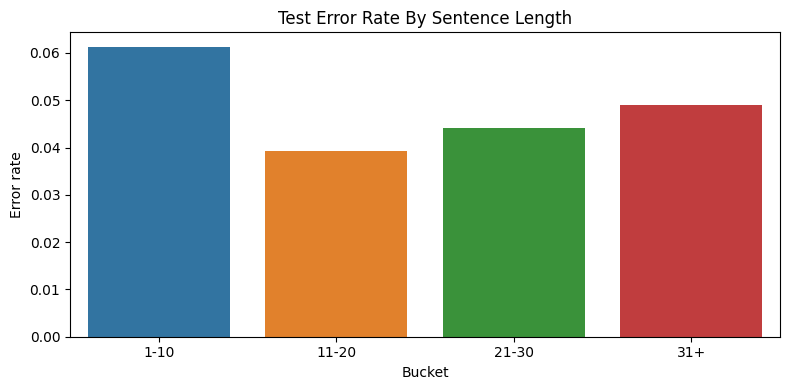

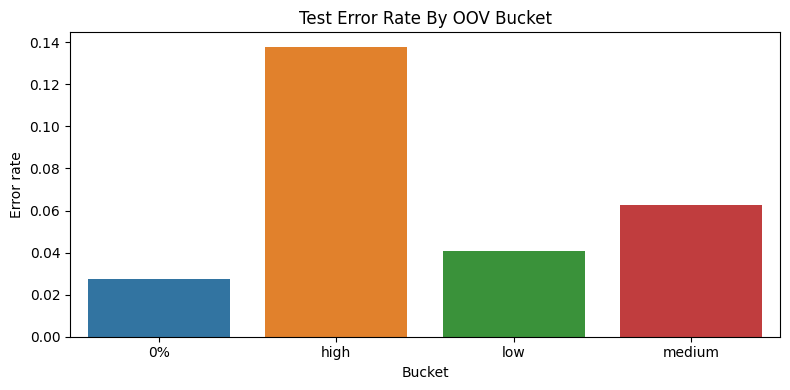

In [10]:
plot_single_model_buckets(model_run, comparison_split)


## Intermediate Conclusion: Robustness Pattern

The error plots show that the BiLSTM is one of the most stable models under sentence-length and OOV stress. This supports the view that contextual neural representations help most when the input is harder to generalize from.


## Detailed Diagnostics


Compact BiLSTM | split = test


,model,split,token_accuracy,macro_f1,train_time_s,inference_time_s,tokens_per_second,model_size_mb,num_sentences,num_tokens,interpretability,implementation_complexity
0,compact_bilstm,test,0.952419,0.904233,574.5724,1.2011,20891.8,11.9991,2077,25094,low,medium


Top tag confusions


,gold_tag,predicted_tag,count
0,PROPN,NOUN,218
1,NOUN,PROPN,158
2,VERB,NOUN,59
3,ADJ,NOUN,57
4,NOUN,ADJ,52
5,SCONJ,ADP,47
6,NOUN,VERB,46
7,ADJ,ADV,43
8,ADV,ADP,41
9,PROPN,ADJ,39


Best and worst per-tag F1


,tag,precision,recall,f1,support
12,PUNCT,0.994199,0.996447,0.995322,3096
4,CCONJ,0.997271,0.993207,0.995235,736
5,DET,0.987448,0.995256,0.991336,1897
3,AUX,0.990921,0.990279,0.990600,1543
10,PRON,0.991204,0.989372,0.990287,2164
9,PART,0.986154,0.987673,0.986913,649
8,NUM,0.960000,0.974170,0.967033,542
1,ADP,0.943863,0.979753,0.961473,2025


,tag,precision,recall,f1,support
2,ADV,0.931799,0.917716,0.924704,1191
7,NOUN,0.910558,0.930876,0.920604,4123
0,ADJ,0.918172,0.909955,0.914045,1788
13,SCONJ,0.931034,0.843750,0.885246,384
11,PROPN,0.900152,0.855904,0.877470,2075
14,SYM,0.873874,0.858407,0.866071,113
6,INTJ,0.915888,0.809917,0.859649,121
16,X,0.571429,0.190476,0.285714,42


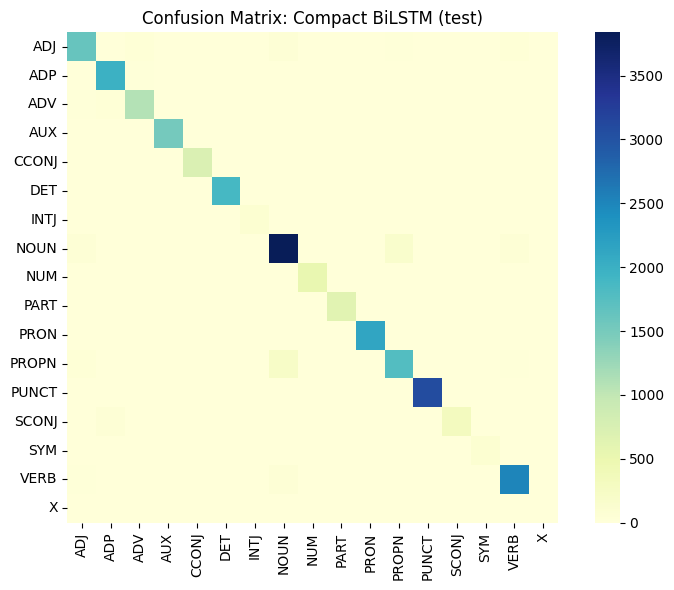

Representative error examples


,sentence_id,oov_rate,length_bucket,oov_bucket,mismatches
0,newsgroup-groups.google.com_HumorUniversity_00...,0.3421,31+,high,"[{'token': 'Twinkle', 'gold': 'VERB', 'pred': ..."
1,weblog-blogspot.com_aggressivevoicedaily_20060...,0.1316,31+,medium,"[{'token': 'Parts', 'gold': 'NOUN', 'pred': 'P..."
2,newsgroup-groups.google.com_JyotishRemedies_cc...,0.2759,21-30,medium,"[{'token': 'interactive', 'gold': 'ADJ', 'pred..."


In [11]:
render_model_diagnostics(model_run, comparison_split)


## Intermediate Conclusion: Error Profile

The BiLSTM wins mainly by reducing the frequency of familiar mistakes, not by changing which mistakes exist. Even the strongest model still struggles with the central `PROPN <-> NOUN` ambiguity, which means the bottleneck is linguistic and contextual, not just architectural.


## Notebook Scope

This notebook contains the full run for this single model: data reload, training, evaluation, plots, and qualitative error inspection.
